In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('CBRN_Chemical_Incidents_Dataset-updated - CBRN_Chemical_Incidents_Dataset.csv')

In [ ]:
# Replace 'critical' with 'high' in the original column
df['threat_level'] = df['threat_level'].replace('critical', 'high')


In [ ]:
df.info()
df.describe()
df.isnull().sum()
df['threat_level'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   event_id                     2000 non-null   object 
 1   latitude                     2000 non-null   float64
 2   longitude                    2000 non-null   float64
 3   chemical_name                2000 non-null   object 
 4   chemical_type                2000 non-null   object 
 5   quantity_released            2000 non-null   float64
 6   temperature                  2000 non-null   float64
 7   humidity                     2000 non-null   float64
 8   precipitation                2000 non-null   object 
 9   wind_speed                   2000 non-null   float64
 10  wind_direction               2000 non-null   float64
 11  nearby_population            2000 non-null   int64  
 12  proximity_sensitive_sites    2000 non-null   float64
 13  emergency_services

,count
threat_level,
high,993
medium,526
low,481


In [ ]:
# Example for numeric features
df.groupby('threat_level')[[
    'quantity_released',
    'LD50', 'LC50', 'IC50', 'lethal_dosage',
    'nearby_population',
    'proximity_sensitive_sites',
    'wind_speed',
    'emergency_services_distance'
]].mean().round(2)



,quantity_released,LD50,LC50,IC50,lethal_dosage,nearby_population,proximity_sensitive_sites,wind_speed,emergency_services_distance
threat_level,,,,,,,,,
high,252.82,1633.77,443.29,2.71,7.51,2452.21,4.97,9.84,9.97
low,257.75,1527.33,405.37,2.42,6.74,2478.72,5.02,9.97,10.17
medium,240.67,1651.23,459.37,2.85,7.88,2465.88,5.00,9.83,10.21


In [ ]:
df['incident_type'].value_counts(normalize=True)
df.groupby('threat_level')['incident_type'].value_counts(normalize=True)


threat_level  incident_type      
high          test                   0.256798
              sabotage               0.253776
              intentional release    0.248741
              accident               0.240685
low           intentional release    0.257796
              test                   0.255717
              accident               0.253638
              sabotage               0.232848
medium        intentional release    0.275665
              accident               0.258555
              sabotage               0.247148
              test                   0.218631
Name: proportion, dtype: float64

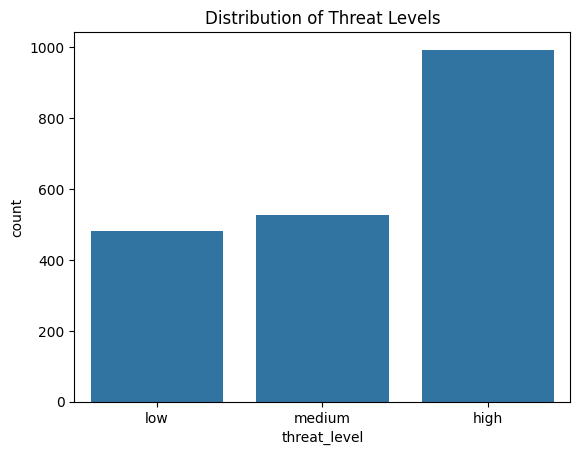

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='threat_level', order=['low', 'medium', 'high'])
plt.title('Distribution of Threat Levels')
plt.show()


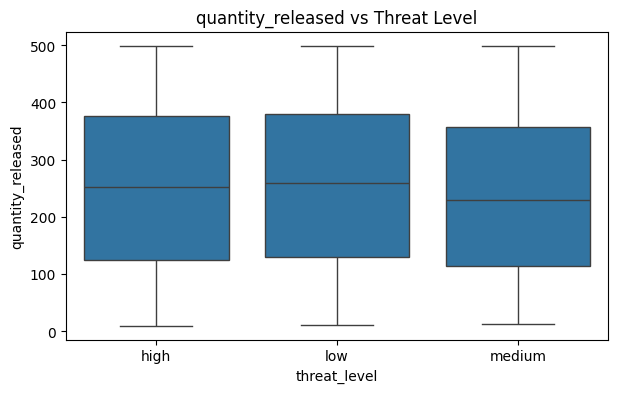

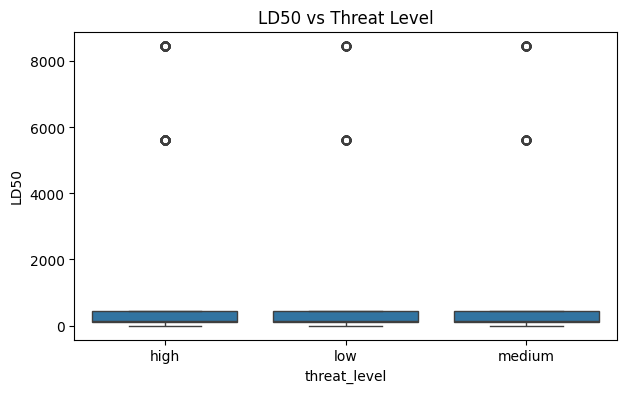

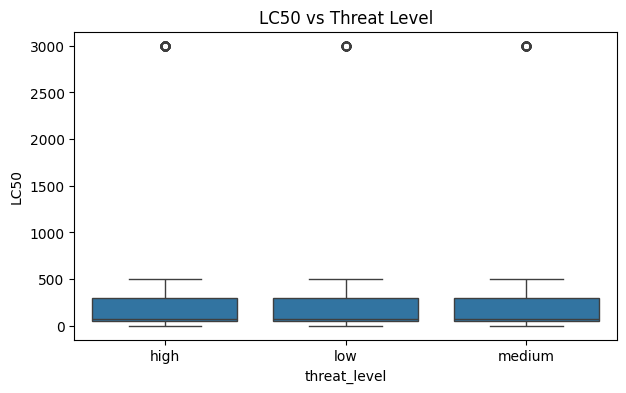

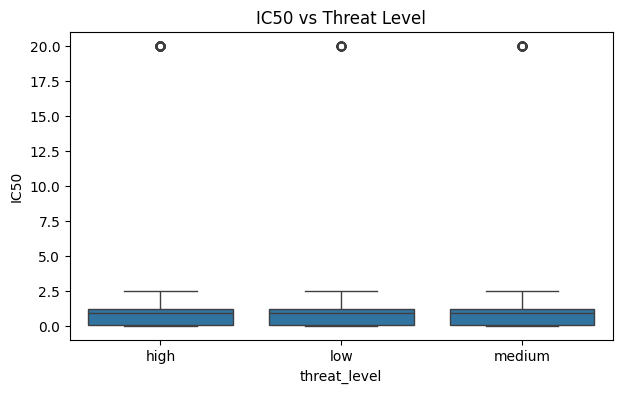

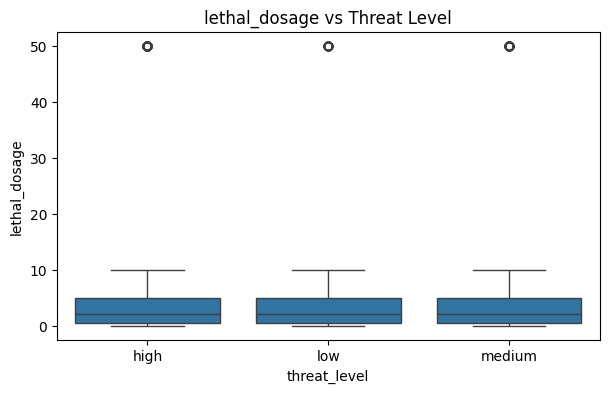

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['quantity_released', 'LD50', 'LC50', 'IC50', 'lethal_dosage']

for feat in features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x='threat_level', y=feat, data=df)
    plt.title(f'{feat} vs Threat Level')
    plt.show()


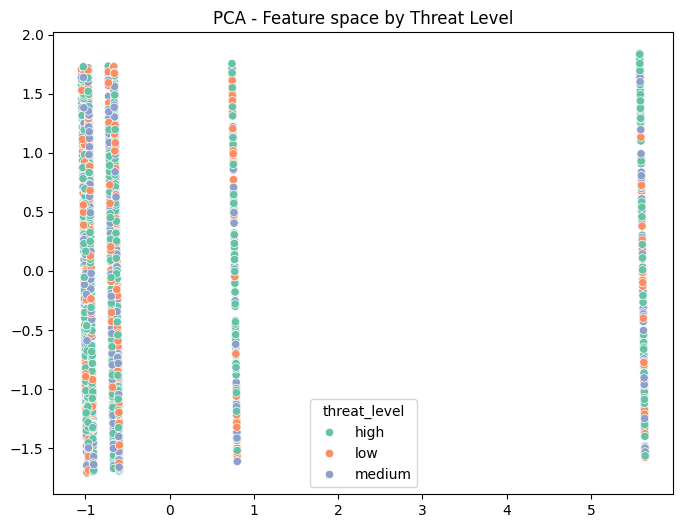

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = df[features]
y = df['threat_level']

# Standardize
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set2')
plt.title('PCA - Feature space by Threat Level')
plt.show()


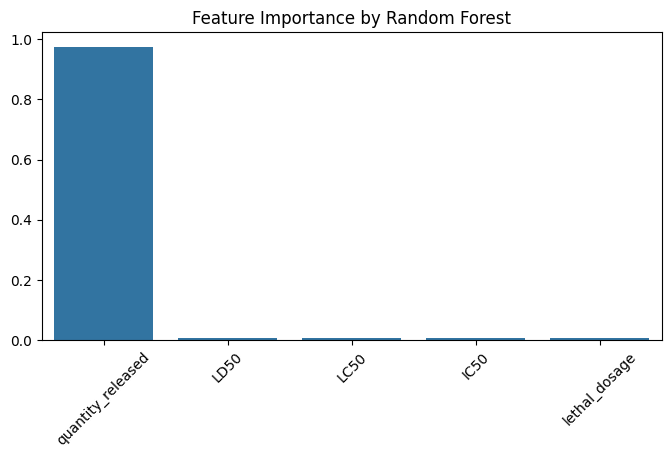

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_scaled, y)
importances = rf.feature_importances_

# Plot
plt.figure(figsize=(8, 4))
sns.barplot(x=features, y=importances)
plt.title('Feature Importance by Random Forest')
plt.xticks(rotation=45)
plt.show()


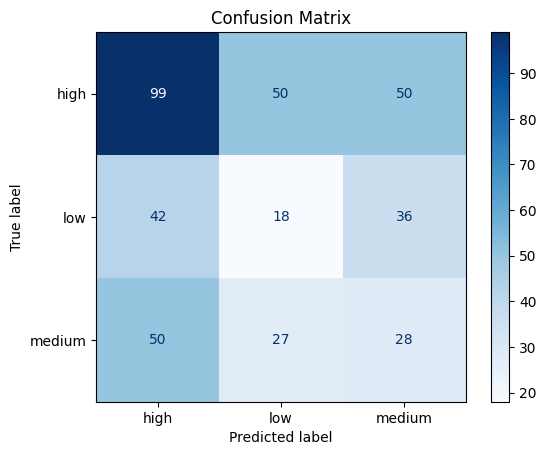

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


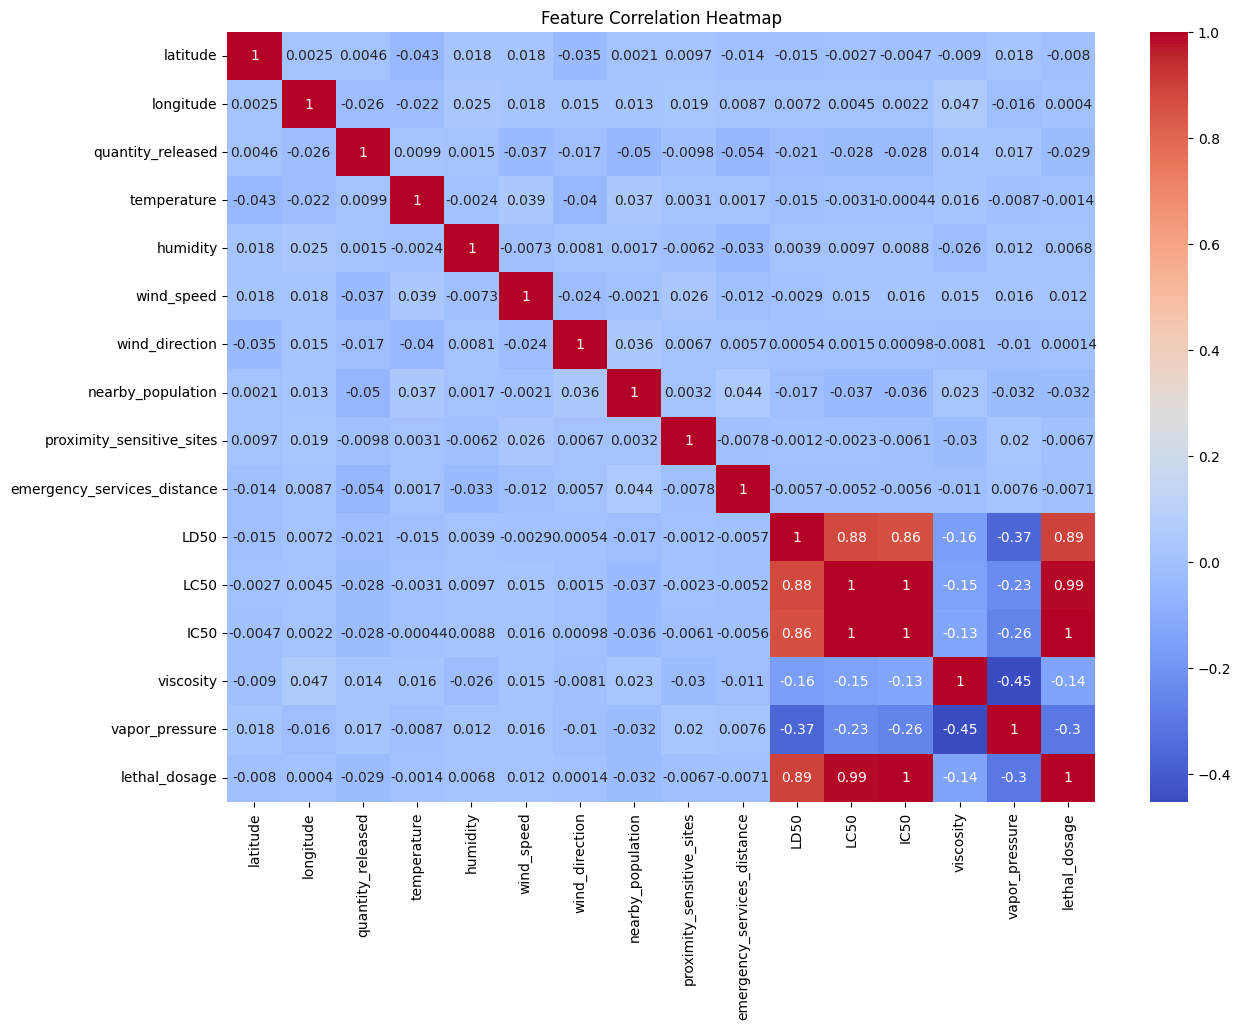

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


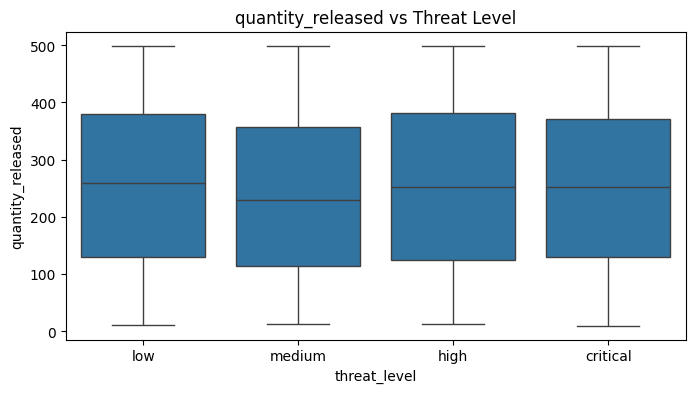

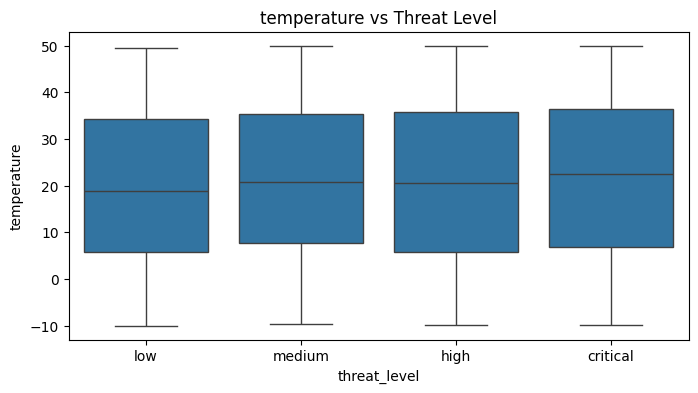

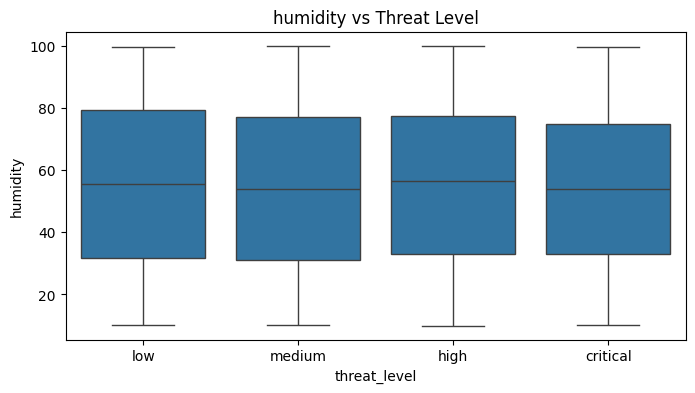

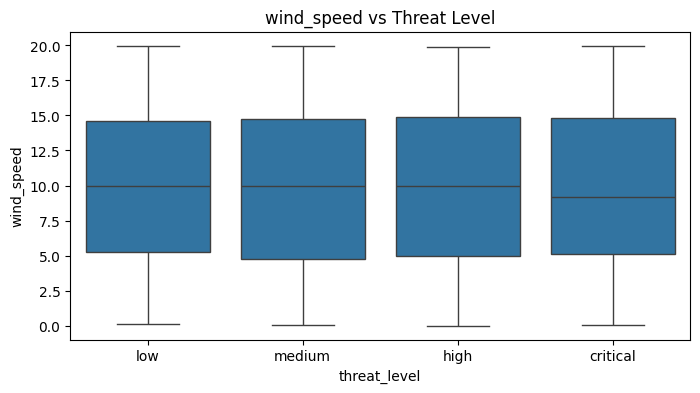

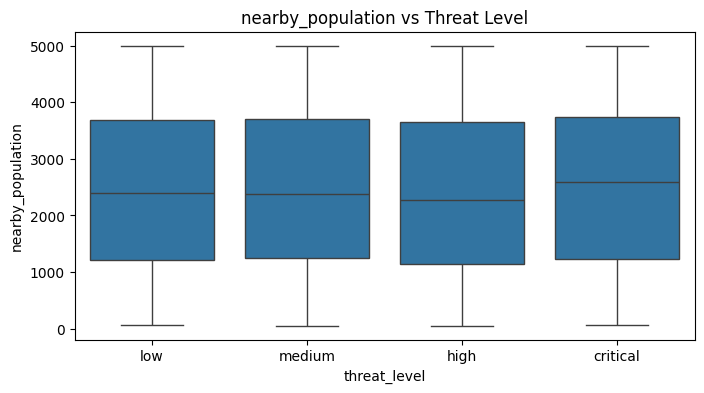

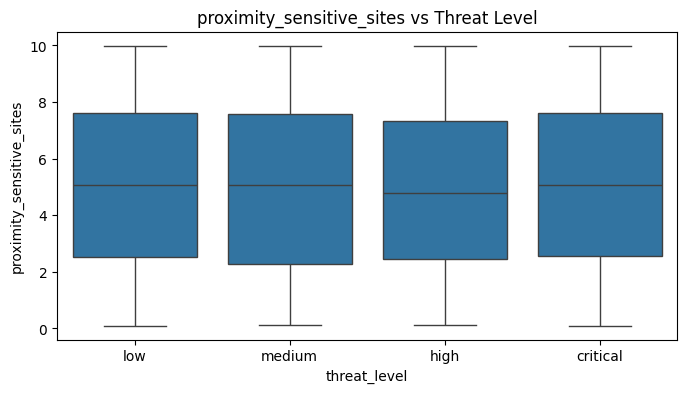

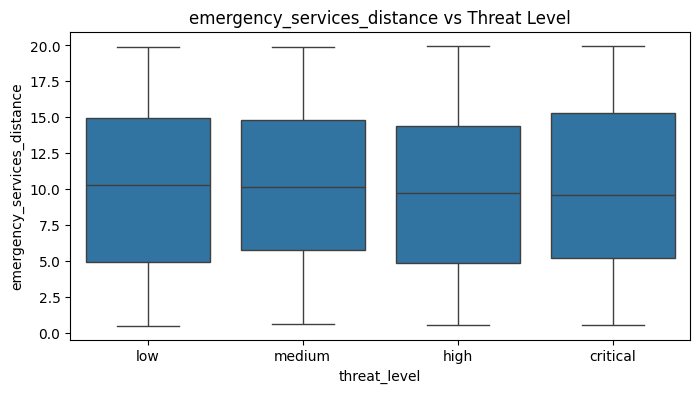

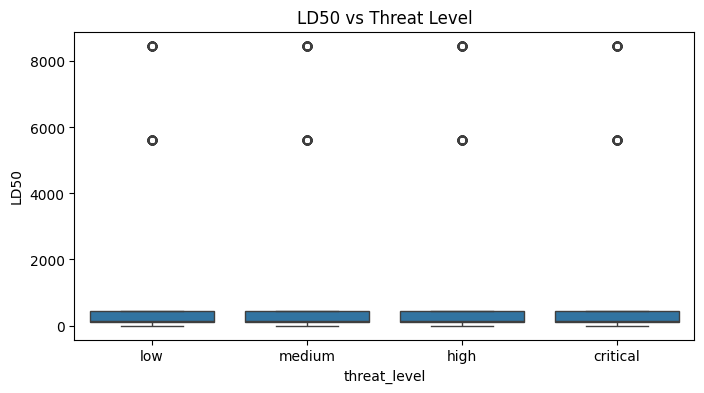

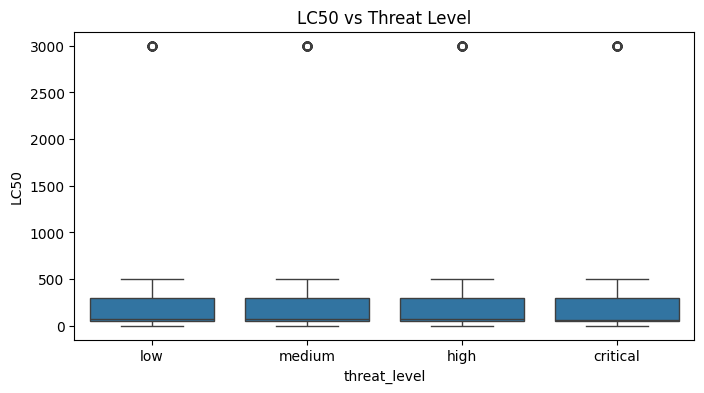

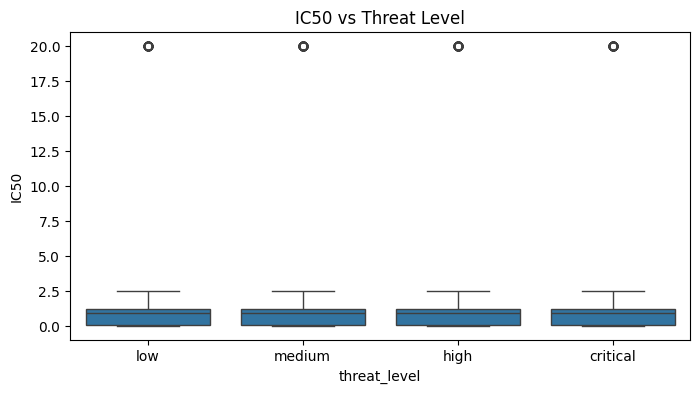

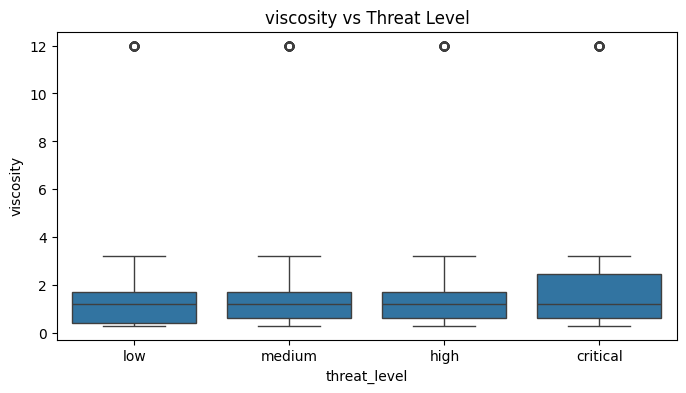

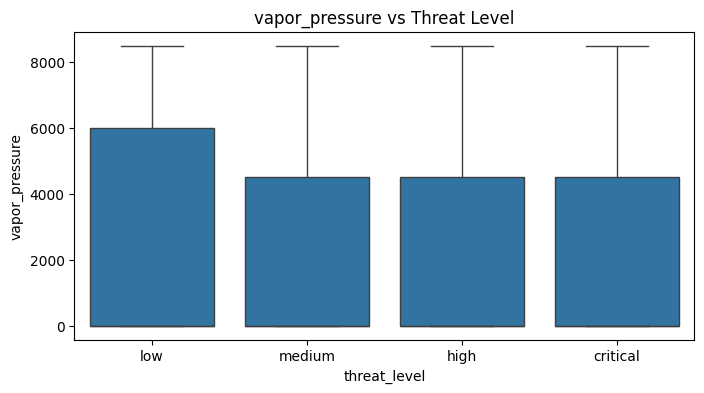

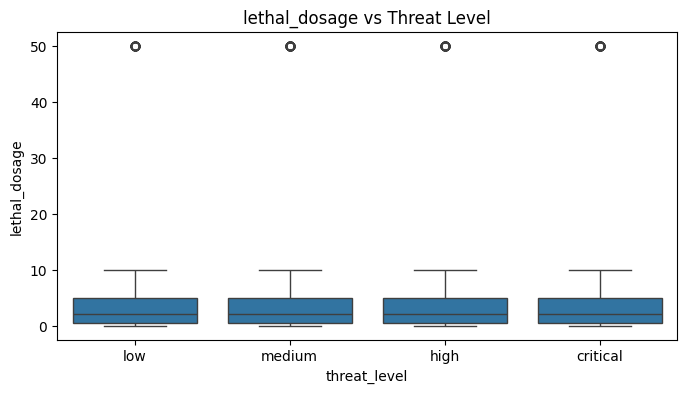

In [ ]:
for col in ['quantity_released', 'temperature', 'humidity', 'wind_speed',
            'nearby_population', 'proximity_sensitive_sites', 'emergency_services_distance',
            'LD50', 'LC50', 'IC50', 'viscosity', 'vapor_pressure', 'lethal_dosage']:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='threat_level', y=col, order=['low', 'medium', 'high', 'critical'])
    plt.title(f'{col} vs Threat Level')
    plt.show()


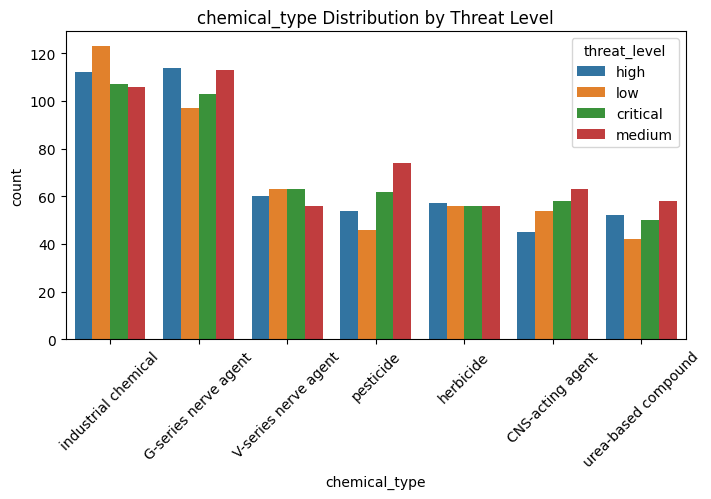

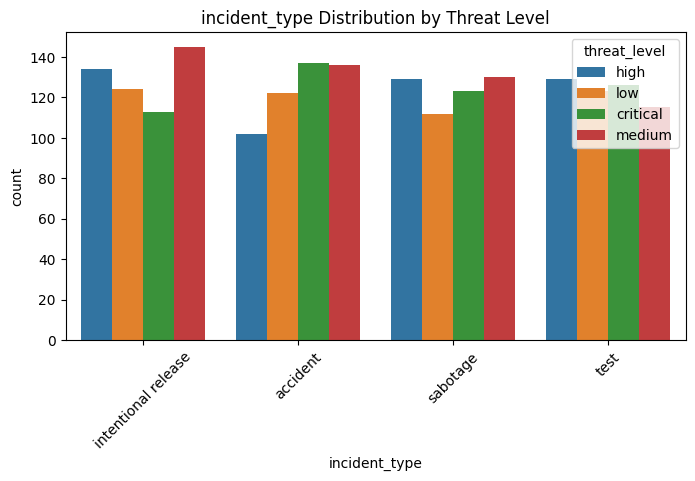

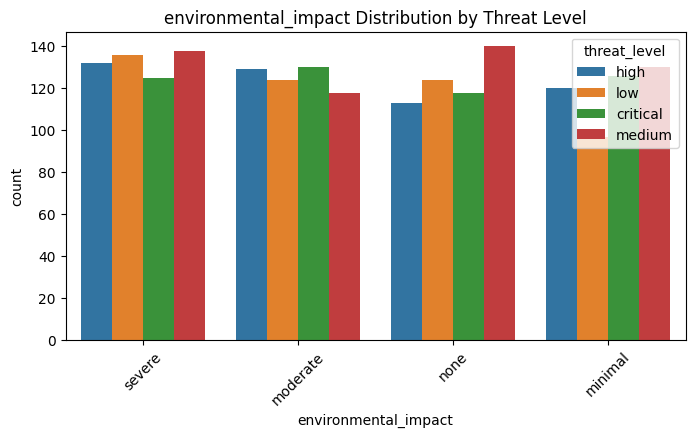

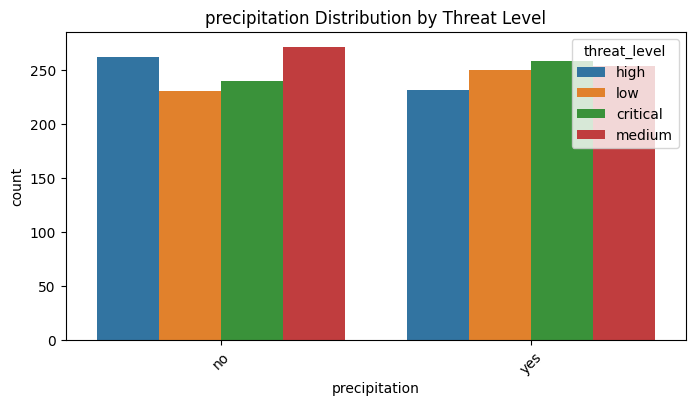

In [ ]:
categorical_cols = ['chemical_type', 'incident_type', 'environmental_impact', 'precipitation']

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue='threat_level', order=df[col].value_counts().index)
    plt.title(f'{col} Distribution by Threat Level')
    plt.xticks(rotation=45)
    plt.show()



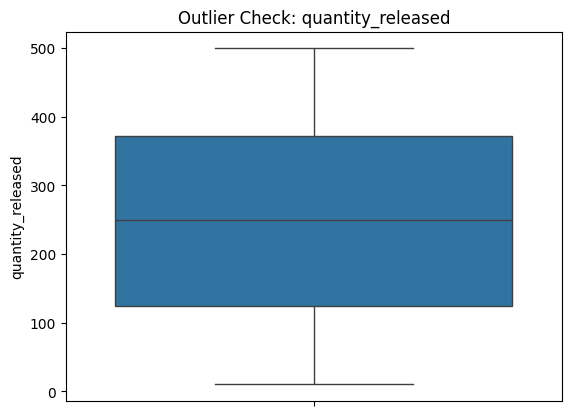

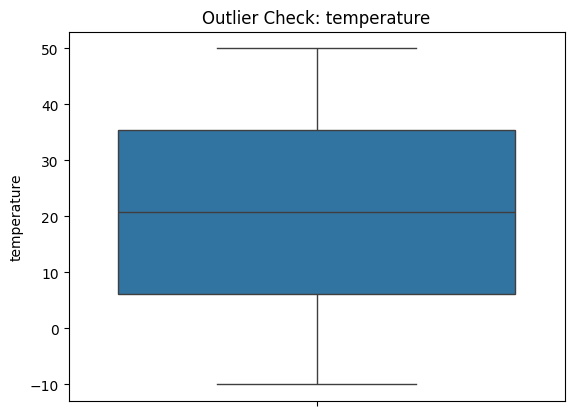

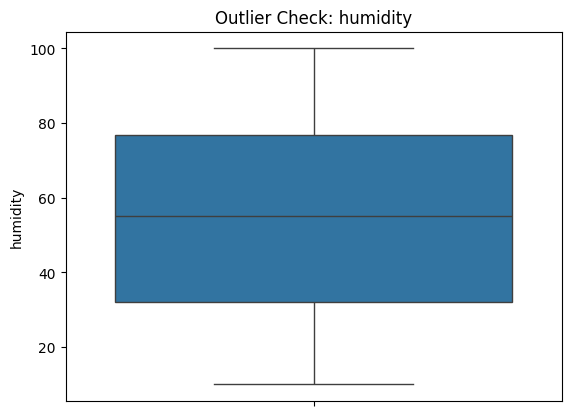

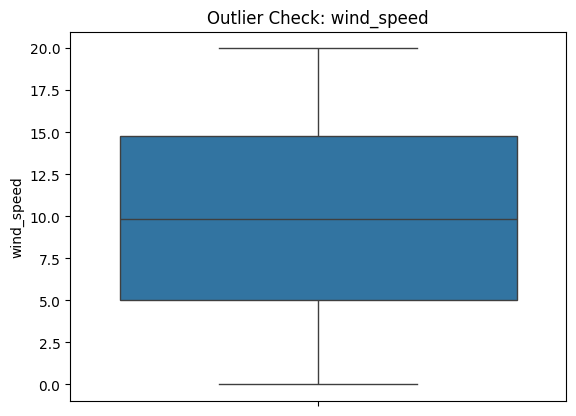

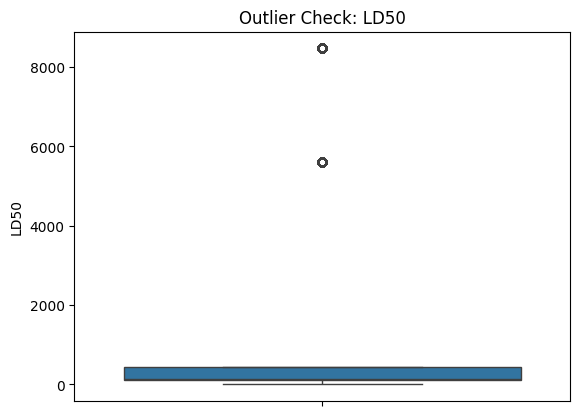

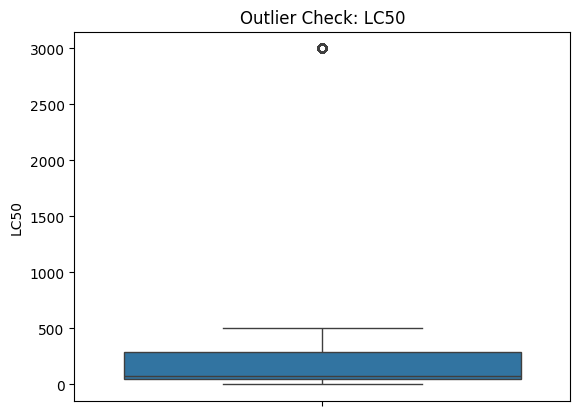

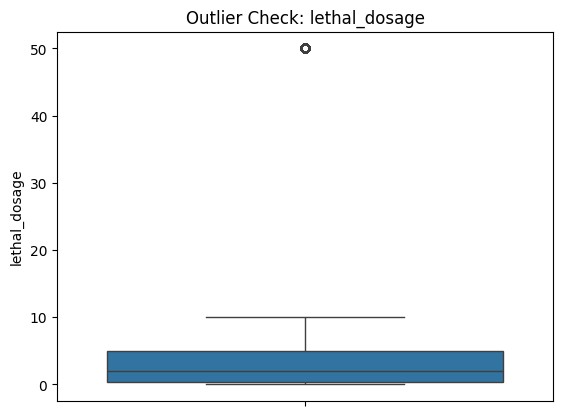

In [ ]:
import seaborn as sns

for col in ['quantity_released', 'temperature', 'humidity', 'wind_speed',
            'LD50', 'LC50', 'lethal_dosage']:
    sns.boxplot(data=df[col])
    plt.title(f'Outlier Check: {col}')
    plt.show()


In [ ]:
df['threat_level'].value_counts()


,count
threat_level,
high,993
medium,526
low,481


In [ ]:
import pandas as pd



# Drop optional columns only if they exist
columns_to_drop = ['event_id', 'date_time', 'chemical_name']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Encode target variable 'threat_level' numerically
threat_map = {'low': 0, 'medium': 1, 'high': 2}
df['threat_level_encoded'] = df['threat_level'].map(threat_map)

# Encode binary column 'precipitation' if it exists
if 'precipitation' in df.columns:
    df['precipitation'] = df['precipitation'].map({'no': 0, 'yes': 1})

# One-hot encode other categorical variables if they exist
categorical_cols = ['chemical_type', 'incident_type', 'environmental_impact']
existing_categoricals = [col for col in categorical_cols if col in df.columns]
df = pd.get_dummies(df, columns=existing_categoricals, drop_first=True)

# Compute correlation with target
correlation_with_target = df.corr(numeric_only=True)['threat_level_encoded'].drop('threat_level_encoded')
correlation_sorted = correlation_with_target.sort_values(ascending=False)

# Print correlations
print("\nCorrelation of each parameter with threat_level:\n")
print(correlation_sorted)



Correlation of each parameter with threat_level:

wind_direction                        0.033625
temperature                           0.029722
incident_type_sabotage                0.019152
chemical_type_pesticide               0.018127
lethal_dosage                         0.017374
chemical_type_urea-based compound     0.016783
IC50                                  0.016302
chemical_type_G-series nerve agent    0.015915
LC50                                  0.014515
LD50                                  0.013190
environmental_impact_moderate         0.009497
incident_type_test                    0.008200
longitude                             0.005983
viscosity                             0.002359
chemical_type_herbicide              -0.001159
chemical_type_V-series nerve agent   -0.003652
latitude                             -0.005376
quantity_released                    -0.005775
proximity_sensitive_sites            -0.007004
nearby_population                    -0.007616
wind_spee

np.float64(0.02230394681458196)

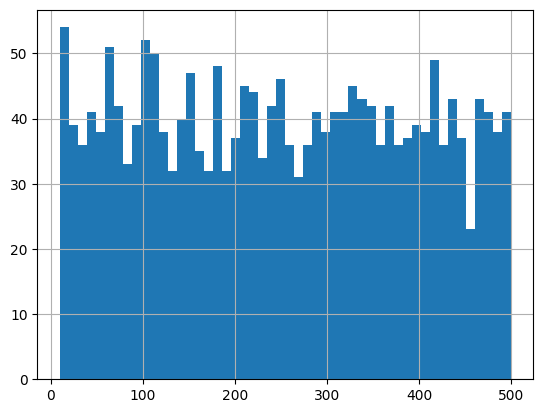

In [ ]:
df['toxicity'].hist(bins=50)
df['toxicity'].skew()


In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['threat_level', 'threat_level_encoded'])
y = df['threat_level_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


In [ ]:
X_train.dtypes[X_train.dtypes == 'object']


,0
threat_level_grouped,object


In [ ]:
# Install the category_encoders library if it's not already installed
!pip install category_encoders

from category_encoders import TargetEncoder

encoder = TargetEncoder()
X_train_encoded = encoder.fit_transform(X_train, y_train)
X_test_encoded = encoder.transform(X_test)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.1 MB/s eta 0:00:00


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_encoded, y_train_encoded)

y_pred_rf = rf.predict(X_test_encoded)


In [ ]:
le.inverse_transform(y_pred_rf)


array([0, 1, 2, 1, 1, 2, 2, 1, 1, 2, 1, 2, 1, 2, 0, 1, 1, 0, 2, 2, 2, 1,
       2, 2, 2, 0, 2, 0, 1, 2, 0, 2, 0, 1, 1, 2, 2, 2, 0, 2, 2, 0, 0, 2,
       1, 2, 2, 1, 2, 1, 2, 2, 1, 0, 2, 0, 1, 2, 2, 0, 0, 0, 1, 2, 0, 0,
       0, 1, 0, 0, 1, 2, 2, 1, 2, 0, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 2, 0, 1, 2, 2, 0, 0, 1, 2,
       2, 1, 2, 2, 2, 2, 0, 0, 2, 2, 2, 1, 2, 2, 2, 0, 0, 1, 0, 0, 0, 2,
       2, 2, 0, 0, 2, 1, 2, 2, 0, 1, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2,
       1, 2, 0, 0, 1, 1, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 2, 0, 1,
       1, 2, 2, 1, 2, 2, 2, 1, 2, 0, 0, 2, 2, 0, 2, 2, 1, 0, 2, 2, 1, 0,
       0, 2, 2, 0, 2, 1, 1, 2, 2, 2, 1, 1, 1, 2, 2, 2, 0, 1, 2, 2, 2, 2,
       2, 0, 2, 0, 1, 1, 2, 1, 0, 2, 1, 1, 2, 0, 2, 2, 1, 1, 1, 2, 1, 2,
       0, 2, 0, 2, 1, 1, 2, 0, 2, 2, 0, 0, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 1, 2, 0, 2, 2, 2, 2, 2, 1, 1, 2, 1, 2, 0, 2, 2, 2, 2, 2, 2,
       2, 2, 1, 0, 0, 2, 1, 2, 2, 1, 0, 2, 2, 0, 0,

In [ ]:
X_train.dtypes[X_train.dtypes == 'object']


,0
threat_level_grouped,object


In [ ]:
X_train = X_train.drop(columns=['threat_level', 'threat_level_grouped'], errors='ignore')
X_test = X_test.drop(columns=['threat_level', 'threat_level_grouped'], errors='ignore')


In [ ]:
from category_encoders import TargetEncoder

encoder = TargetEncoder()
X_train_encoded = encoder.fit_transform(X_train, y_train)
X_test_encoded = encoder.transform(X_test)


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:21:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(estimators=[
    ('rf', rf),
    ('xgb', xgb)
], voting='soft')  # soft = probability averaging

voting_clf.fit(X_train, y_train)
y_pred_vote = voting_clf.predict(X_test)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:21:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack = StackingClassifier(estimators=[
    ('rf', rf),
    ('xgb', xgb)
], final_estimator=LogisticRegression())

stack.fit(X_train, y_train)
y_pred_stack = stack.predict(X_test)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:21:37] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:21:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:21:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:21:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:21:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

In [ ]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=7)
lgbm.fit(X_train, y_train)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000259 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2623
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 29
[LightGBM] [Info] Start training from score -1.424516
[LightGBM] [Info] Start training from score -1.335126
[LightGBM] [Info] Start training from score -0.700675
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further

LGBMClassifier(learning_rate=0.05, max_depth=7, n_estimators=300)

In [ ]:
from sklearn.metrics import classification_report

print("Random Forest:\n", classification_report(y_test, y_pred_rf))
print("XGBoost:\n", classification_report(y_test, y_pred_xgb))
print("Voting Classifier:\n", classification_report(y_test, y_pred_vote))
print("Stacking Classifier:\n", classification_report(y_test, y_pred_stack))


Random Forest:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        96
           1       1.00      1.00      1.00       105
           2       1.00      1.00      1.00       199

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

XGBoost:
               precision    recall  f1-score   support

           0       0.28      0.14      0.18        96
           1       0.24      0.16      0.19       105
           2       0.50      0.71      0.59       199

    accuracy                           0.43       400
   macro avg       0.34      0.34      0.32       400
weighted avg       0.38      0.43      0.39       400

Voting Classifier:
               precision    recall  f1-score   support

           0       0.29      0.10      0.15        96
           1       0.27      0.12      0.17       105
           2       0.50      

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(X_train.equals(X_test))  # should return False


False


In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Define base models
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
logreg = LogisticRegression(max_iter=1000)

# Voting Classifier (Soft Voting recommended if models provide probabilities)
voting_model = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('lr', logreg)],
    voting='soft'  # change to 'hard' for majority class vote
)

# Train
voting_model.fit(X_train, y_train)

# Predict & Evaluate
y_pred = voting_model.predict(X_test)
print("Voting Classifier Report:\n")
print(classification_report(y_test, y_pred))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:22:28] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Voting Classifier Report:

              precision    recall  f1-score   support

           0       0.33      0.09      0.15        96
           1       0.35      0.06      0.10       105
           2       0.51      0.90      0.65       199

    accuracy                           0.49       400
   macro avg       0.40      0.35      0.30       400
weighted avg       0.42      0.49      0.38       400



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Step 1: Impute NaNs
imputer = SimpleImputer(strategy='mean')  # or use 'median' or 'most_frequent'
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Step 2: Define models
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(eval_metric='mlogloss')  # remove use_label_encoder (deprecated)
logreg = LogisticRegression(max_iter=1000)

# Step 3: Voting ensemble
voting_model = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('lr', logreg)],
    voting='soft'
)

# Step 4: Train and evaluate
voting_model.fit(X_train_imputed, y_train)
y_pred = voting_model.predict(X_test_imputed)
print("Voting Classifier Report:\n")
print(classification_report(y_test, y_pred))


Voting Classifier Report:

              precision    recall  f1-score   support

           0       0.33      0.09      0.15        96
           1       0.35      0.06      0.10       105
           2       0.51      0.90      0.65       199

    accuracy                           0.49       400
   macro avg       0.40      0.35      0.30       400
weighted avg       0.42      0.49      0.38       400



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# DROP completely NaN column
X_train = X_train.drop(columns=['precipitation'])
X_test = X_test.drop(columns=['precipitation'])

# Pipelines for each model
rf_pipeline = make_pipeline(SimpleImputer(strategy='mean'), RandomForestClassifier(n_estimators=100, random_state=42))
xgb_pipeline = make_pipeline(SimpleImputer(strategy='mean'), XGBClassifier(eval_metric='mlogloss'))
lr_pipeline = make_pipeline(SimpleImputer(strategy='mean'), StandardScaler(), LogisticRegression(max_iter=2000))

# Voting ensemble
voting_model = VotingClassifier(
    estimators=[
        ('rf', rf_pipeline),
        ('xgb', xgb_pipeline),
        ('lr', lr_pipeline)
    ],
    voting='soft'
)

# Train and evaluate
voting_model.fit(X_train, y_train)
y_pred = voting_model.predict(X_test)
print("Voting Classifier Report:\n")
print(classification_report(y_test, y_pred))


Voting Classifier Report:

              precision    recall  f1-score   support

           0       0.26      0.28      0.27        96
           1       0.31      0.33      0.32       105
           2       0.23      0.21      0.22        99
           3       0.24      0.22      0.23       100

    accuracy                           0.26       400
   macro avg       0.26      0.26      0.26       400
weighted avg       0.26      0.26      0.26       400



In [ ]:
y_train.value_counts(normalize=True)


,proportion
threat_level_encoded,
1,0.263125
3,0.249375
2,0.246875
0,0.240625
